# Exercise on denoising autoencoders
This exercise explores how denoising autoencoders push the denoised sample towards the data manifold.

In [76]:
# make a 2d Dataset
import numpy as np

def generating_function(t):
    return np.array([0.04*t*np.sin(t), 0.04*t*np.cos(t)]).T

t = np.random.uniform(3, 12, 1000)
data = generating_function(t)

data

array([[-0.07995682,  0.22374096],
       [-0.06341333, -0.12919158],
       [-0.39496695,  0.23886633],
       ...,
       [-0.34426924,  0.31960446],
       [-0.36745114,  0.28717513],
       [-0.15576725, -0.07132362]])

In [ ]:
import torch
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_size=1000, noise_std=0.1):
        super().__init__()
        self.b = nn.Parameter(torch.randn(latent_size))
        self.W = nn.Parameter(torch.randn(2,latent_size))
        self.c = nn.Parameter(torch.randn(2))
        self.V = nn.Parameter(torch.randn(latent_size,2))
        self.noise_std = noise_std

    def add_noise(self, x):
        noise = torch.randn_like(x) * self.noise_std
        return x + noise

    def forward(self, x):
        if self.training:
            noisy_x = self.add_noise(x)
        encoded = torch.tanh(torch.matmul(noisy_x, self.W) + self.b)
        decoded = torch.matmul(encoded, self.V) + self.c
        return decoded

In [ ]:
# train the autoencoder
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# create the model
model = DenoisingAutoencoder(noise_std=0.01, latent_size=1000).to(device=device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

model.train()
# Training loop
# NOTE: 10000 epochs could still give bad results so you may try to increase it e.g. to 15000 or more. In practice this could cause overfitting if the task is easy but in this case we are more focused on observing the behavior of the model rather than achieving a nice result without overfitting.
for epoch in range(10000):
    data_tensor = data_tensor[torch.randperm(data_tensor.size(0))]  # shuffle data each epoch

    for i in range(0, data_tensor.size(0), 100):
        batch = data_tensor[i:i+100]
        pred = model(batch)
        pred = pred.squeeze()
        loss = loss_fn(pred, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:<4} | reconstruction loss = {loss.item():.4f}")


Epoch 0    | reconstruction loss = 381.1443
Epoch 1000 | reconstruction loss = 0.0024
Epoch 2000 | reconstruction loss = 0.0003
Epoch 3000 | reconstruction loss = 0.0002
Epoch 4000 | reconstruction loss = 0.0002
Epoch 5000 | reconstruction loss = 0.0002
Epoch 6000 | reconstruction loss = 0.0001
Epoch 7000 | reconstruction loss = 0.0001
Epoch 8000 | reconstruction loss = 0.0002
Epoch 9000 | reconstruction loss = 0.0002


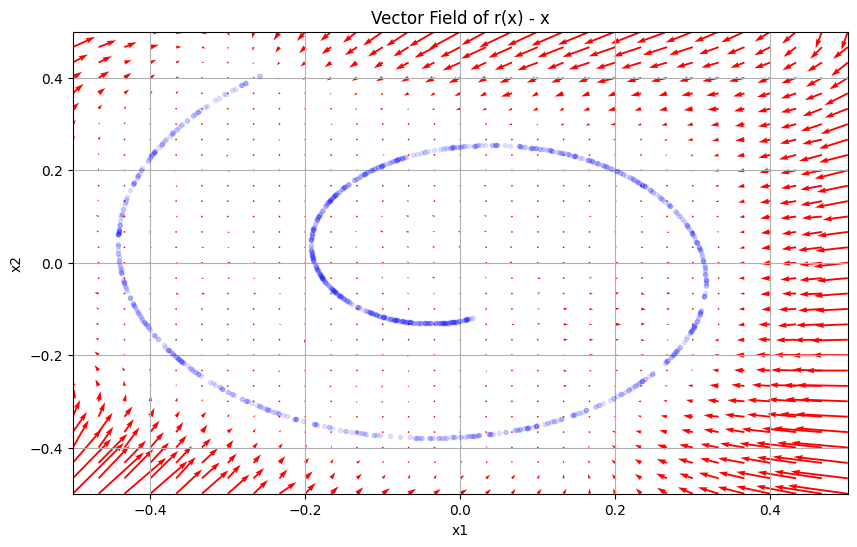

In [94]:
# plot r(x)-x as vector field
import matplotlib.pyplot as plt

model.eval()

x = torch.linspace(-0.5, 0.5, 31)
y = torch.linspace(-0.5, 0.5, 31)

X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.ravel(), Y.ravel()], dim=-1).to(device)

# find directions of r(x) - x
with torch.no_grad():
    output = model(grid_points)
    loss = loss_fn(output, grid_points)
residual = np.multiply(output - grid_points, 0.1)  # scale down for better visualization
residual = residual.cpu().numpy()

# Plot the vector field
plt.figure(figsize=(10, 6))
plt.quiver(grid_points[:, 0], grid_points[:, 1],
           residual[:, 0], residual[:, 1],
           angles='xy', scale_units='xy', scale=1, color='r')
plt.plot(data[:, 0], data[:, 1], 'b.', alpha=0.1)  # Plot the original data points
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.grid()
plt.title("Vector Field of r(x) - x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()